In [1]:
#make sure to set the scenario in drivers.py to your selected scenario (SSP2) is the only option right now. 
# set the scenario to the correct ones in the other pre-processing files as well (lifetime, materials, capacity) to ensure that the correct data is used for the model.

from pathlib import Path
import prism
import pandas as pd
import numpy as np
import xarray as xr
import scipy
import matplotlib.pyplot as plt

YEAR_START = 1971   # start year of the simulation period
YEAR_END = 2100     # end year of the calculations
YEAR_OUT = 2100     # year of output generation = last year of reporting
year_end = 2100     # end year of the calculations
year_out = 2100
year_start = 1971 

from imagematerials.model import GenericStocks, MaterialIntensities, SharesInflowStocks
from imagematerials.factory import ModelFactory, Sector
from imagematerials.preprocessing import get_preprocessing_data
from imagematerials.fossil_fuels.preprocessing.ffconstants import (path_base,STANDARD_SCEN_EXTERNAL_DATA)

#define path base or current path?

circular_economy_config = None
climate_policy_config = "SSP2_baseline" #SSP2_baseline is the only option right now given the existing files of primpersec and final_energy_rt
scenario = "SSP2_baseline" #SSP2_baseline is the only option right now given the existing files of primpersec and final_energy_rt


lifetimes.py ran successfully!
materials.py ran successfully!
drivers.py ran successfully!
capacity.py ran successfully!
main.py ran successfully!


In [3]:
from imagematerials.fossil_fuels.preprocessing.ffconstants import REGIONS_TIMER

In [4]:
from imagematerials.fossil_fuels.preprocessing.main import get_preprocessing_data_extraction
from imagematerials.fossil_fuels.preprocessing.main import get_preprocessing_data_processing
from imagematerials.fossil_fuels.preprocessing.main import get_preprocessing_data_transport
from imagematerials.fossil_fuels.preprocessing.main import get_preprocessing_data_pipelines

In [5]:

scenario_list = {"SSP2_baseline":("SSP2_baseline", None),
                 }


time_start = 1971
complete_timeline = prism.Timeline(time_start, YEAR_END, 1)
simulation_timeline = prism.Timeline(YEAR_START, YEAR_END, 1)

all_output = {}

for scen_id, (climate_scen, circular_scen) in scenario_list.items():
    climate_policy_scenario_dir = Path(path_base, "data", "raw", "image", climate_scen)
    circular_economy_scenario_dir = None 
    scenario = path_base /"fossil_fuels"/ STANDARD_SCEN_EXTERNAL_DATA


    sec_ff = get_preprocessing_data("fossil_fuels", path_base,
                                        climate_policy_scenario_dir, 
                                        circular_economy_scenario_dir, cache = False) 
    # ff_sector is a list of preprocessing data for each fossil fuel subsector

    factory = ModelFactory(
    sec_ff, complete_timeline
    ).add(GenericStocks, ["ff_extr",
                         "ff_proc",
                         "ff_trp",
                         "ff_pipe"
                          ]
    ).add(MaterialIntensities, ["ff_extr",
                         "ff_proc",
                         "ff_trp",
                         "ff_pipe"
                          ]
    )
    model = factory.finish()

    model.simulate(simulation_timeline)
    all_output[scen_id] = model
    print(f"Finished {scen_id}")



[[[30.  30.  15.  50.  15.  30. ]
  [30.  30.  15.  50.  15.  30. ]
  [30.  30.  15.  50.  15.  30. ]
  ...
  [30.  30.  15.  50.  15.  30. ]
  [30.  30.  15.  50.  15.  30. ]
  [30.  30.  15.  50.  15.  30. ]]

 [[ 9.   9.   4.5 15.   4.5  9. ]
  [ 9.   9.   4.5 15.   4.5  9. ]
  [ 9.   9.   4.5 15.   4.5  9. ]
  ...
  [ 9.   9.   4.5 15.   4.5  9. ]
  [ 9.   9.   4.5 15.   4.5  9. ]
  [ 9.   9.   4.5 15.   4.5  9. ]]]
[[[30.  60.  47.  20. ]
  [30.  60.  47.  20. ]
  [30.  60.  47.  20. ]
  ...
  [30.  60.  47.  20. ]
  [30.  60.  47.  20. ]
  [30.  60.  47.  20. ]]

 [[ 9.  18.  14.1  6. ]
  [ 9.  18.  14.1  6. ]
  [ 9.  18.  14.1  6. ]
  ...
  [ 9.  18.  14.1  6. ]
  [ 9.  18.  14.1  6. ]
  [ 9.  18.  14.1  6. ]]]
shape: (2, 221, 6)
['Gas Distribution Pipeline' 'Gas Transmission Pipeline'
 'Oil Offshore Crude Pipeline' 'Oil Onshore Crude Pipeline'
 'Oil Offshore Product Pipeline' 'Oil Onshore Product Pipeline']
[50. 50. 50. 50. 50. 50. 50. 50. 50. 50.]
[[[26.8  26.   26.   ... 26. 

In [6]:
all_output["SSP2_baseline"].ff_extr.keys()

dict_keys(['lifetimes', 'stocks', 'material_intensities', 'knowledge_graph', 'set_unit_flexible', 'outflow_by_cohort', 'inflow', 'stock_by_cohort', 'stock_by_cohort_materials', 'inflow_materials', 'outflow_by_cohort_materials'])

In [ ]:
# All output to array to see dimensions and sometimes to plot because the key returned by the model is an xarray dataset.
all_output["SSP2_baseline"].ff_extr["outflow_by_cohort_materials"].to_array()

# all_output["SSP2_baseline"].ff_extr["outflow_by_cohort_materials"].to_array().sel(Region= "CAN",material = "steel").sum(dim = "Type").plot()
# all_output["SSP2_baseline"].ff_extr["outflow_by_cohort_materials"].to_array().sel(Region= "USA",material = "aluminium").sum(dim = "Type").plot()
# all_output["SSP2_baseline"].ff_extr["inflow_materials"].to_array().sel(Region=1,material = "steel").sum(dim = "Type").plot()


<xarray.DataArray (Region: 26, Type: 6, material: 3)> Size: 4kB
<Quantity([[[1.09970020e+02 3.66566734e-01 0.00000000e+00]
  [1.62929102e+03 4.88787305e+01 0.00000000e+00]
  [1.03284100e+03 0.00000000e+00 1.27948959e+01]
  [8.97303074e+02 0.00000000e+00 0.00000000e+00]
  [3.67436158e+03 4.17541089e-02 4.34242732e+02]
  [1.43134672e+04 2.12031586e-02 3.33268790e+02]]

 [[3.45780158e+03 1.15260053e+01 0.00000000e+00]
  [1.75941443e+04 5.27824328e+02 0.00000000e+00]
  [9.01128267e+03 0.00000000e+00 1.11632308e+02]
  [9.29181283e+03 0.00000000e+00 0.00000000e+00]
  [2.94406581e+04 3.34552933e-01 3.47935050e+03]
  [1.39321458e+05 2.06382907e-01 3.24390261e+03]]

 [[3.56009171e+01 1.18669724e-01 0.00000000e+00]
  [5.27455157e+02 1.58236547e+01 0.00000000e+00]
  [7.26500294e+02 0.00000000e+00 8.99992902e+00]
  [3.64456700e+02 0.00000000e+00 0.00000000e+00]
  [3.35534385e+03 3.81289074e-02 3.96540637e+02]
  [1.90784502e+04 2.82617340e-02 4.44214661e+02]]
...
 [[3.77805392e+02 1.25935131e+00 0.

In [ ]:
# you can also save the steps in between in a variable to avoid repeating the same things, for example:
# save the model output of a specific scenario
# model_scenario_x = all_output["SSP2_baseline"]
# save a certain variable
# gen_inflow_global = model_scenario_x.elc_gen["inflow"].to_array().sum(["Region"])

# #To change a unit do this:
# var = model_scenario_x.elc_gen["inflow_materials"].to_array().pint.to("megaton")

# # If you automatically want to have the correct unit printed in a figure you can do:
# unit = "megaton"
# var = model_scenario_x.elc_gen["inflow_materials"].to_array().pint.to(unit)

# fig, ax = plt.subplots(figsize=(8,6))

# plt.ylabel(f"material inflow ({unit})", fontsize=14)


AttributeError: 'MainModule' object has no attribute 'elc_gen'

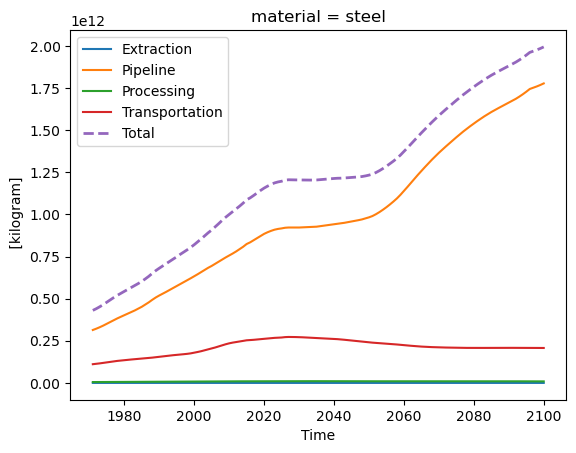

In [8]:
#the key for the stock by cohort materials is already in xarray format, so we can directly select the material and region and plot it.

#plot for steel in all regions and types for each sector plotted on the same graph to compare the sectors.
extr = all_output["SSP2_baseline"].ff_extr["stock_by_cohort_materials"].sel(material="steel").sum(dim="Type").sum(dim="Region")
extr.plot(label="Extraction")

pipe = all_output["SSP2_baseline"].ff_pipe["stock_by_cohort_materials"].sel(material="steel").sum(dim="Type").sum(dim="Region")
pipe.plot(label="Pipeline")

proc = all_output["SSP2_baseline"].ff_proc["stock_by_cohort_materials"].sel(material="steel").sum(dim="Type").sum(dim="Region")
proc.plot(label="Processing")

trp = all_output["SSP2_baseline"].ff_trp["stock_by_cohort_materials"].sel(material="steel").sum(dim="Type").sum(dim="Region")
trp.plot(label="Transportation")

# Sum of all
total = extr + pipe + proc + trp
total.plot(label="Total", linewidth=2, linestyle="--")

plt.legend()

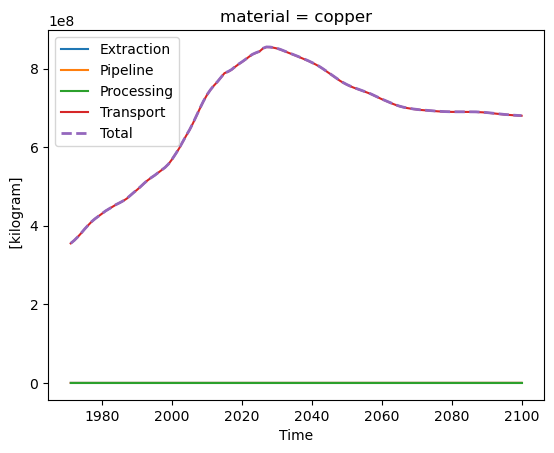

In [9]:
# plot for copper in all regions and types for each sector plotted on the same graph to compare the sectors.
extr = all_output["SSP2_baseline"].ff_extr["stock_by_cohort_materials"].sel(material = "copper").sum(dim = "Type").sum(dim = "Region")
extr.plot(label="Extraction")
pipe = all_output["SSP2_baseline"].ff_pipe["stock_by_cohort_materials"].sel(material = "copper").sum(dim = "Type").sum(dim = "Region")
pipe.plot(label="Pipeline")
proc = all_output["SSP2_baseline"].ff_proc["stock_by_cohort_materials"].sel(material = "copper").sum(dim = "Type").sum(dim = "Region")
proc.plot(label="Processing")
trp = all_output["SSP2_baseline"].ff_trp["stock_by_cohort_materials"].sel(material = "copper").sum(dim = "Type").sum(dim = "Region")
trp.plot(label="Transport")

# Sum of all
total = extr + pipe + proc + trp
total.plot(label="Total", linewidth=2, linestyle="--")

plt.legend()

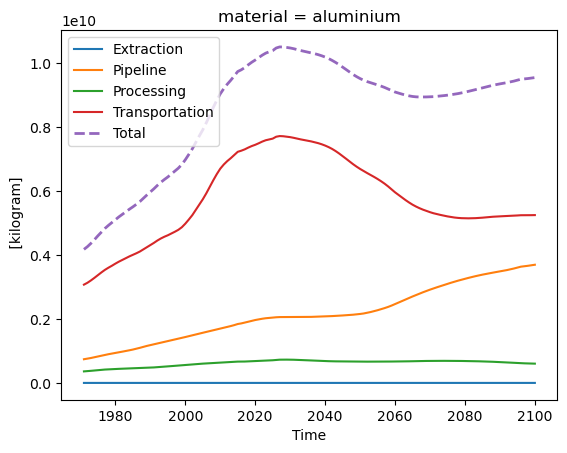

In [10]:
# plot for aluminium in all regions and types for each sector plotted on the same graph to compare the sectors.
extr = all_output["SSP2_baseline"].ff_extr["stock_by_cohort_materials"].sel(material = "aluminium").sum(dim = "Type").sum(dim = "Region")
extr.plot(label="Extraction")
pipe = all_output["SSP2_baseline"].ff_pipe["stock_by_cohort_materials"].sel(material = "aluminium").sum(dim = "Type").sum(dim = "Region")
pipe.plot(label="Pipeline")
proc = all_output["SSP2_baseline"].ff_proc["stock_by_cohort_materials"].sel(material = "aluminium").sum(dim = "Type").sum(dim = "Region")
proc.plot(label="Processing")
trp = all_output["SSP2_baseline"].ff_trp["stock_by_cohort_materials"].sel(material = "aluminium").sum(dim = "Type").sum(dim = "Region")
trp.plot(label="Transportation")

# Sum of all
total = extr + pipe + proc + trp
total.plot(label="Total", linewidth=2, linestyle="--")

plt.legend()

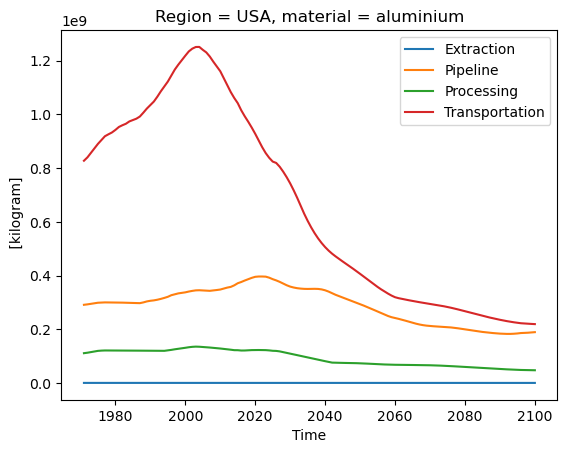

In [11]:
# plot for aluminium in all regions and types for each sector plotted on the same graph to compare the sectors.
all_output["SSP2_baseline"].ff_extr["stock_by_cohort_materials"].sel(material = "aluminium", Region = "USA").sum(dim = "Type").plot(label="Extraction")
all_output["SSP2_baseline"].ff_pipe["stock_by_cohort_materials"].sel(material = "aluminium", Region = "USA").sum(dim = "Type").plot(label="Pipeline")
all_output["SSP2_baseline"].ff_proc["stock_by_cohort_materials"].sel(material = "aluminium", Region = "USA").sum(dim = "Type").plot(label="Processing")
all_output["SSP2_baseline"].ff_trp["stock_by_cohort_materials"].sel(material = "aluminium", Region = "USA").sum(dim = "Type").plot(label="Transportation")

plt.legend()

time
2019    2.114706e+10
2050    2.795167e+10
dtype: float64


/Applications/anaconda3/envs/imagepy312_dev/lib/python3.12/site-packages/xarray/core/variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


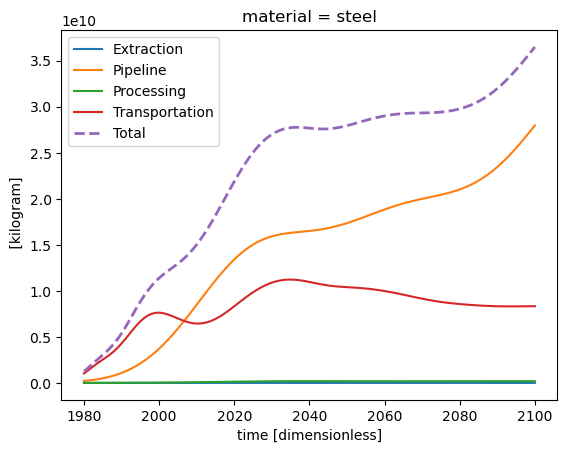

In [25]:
#plot for steel in all regions and types for each sector plotted on the same graph to compare the sectors.
extr = all_output["SSP2_baseline"].ff_extr["outflow_by_cohort_materials"].to_array().sel(material="steel").sel(time=slice(1980, 2100)).sum(dim="Type").sum(dim="Region")
extr.plot(label="Extraction")

pipe = all_output["SSP2_baseline"].ff_pipe["outflow_by_cohort_materials"].to_array().sel(material="steel").sel(time=slice(1980, 2100)).sum(dim="Type").sum(dim="Region")
pipe.plot(label="Pipeline")

proc = all_output["SSP2_baseline"].ff_proc["outflow_by_cohort_materials"].to_array().sel(material="steel").sel(time=slice(1980, 2100)).sum(dim="Type").sum(dim="Region")
proc.plot(label="Processing")

trp = all_output["SSP2_baseline"].ff_trp["outflow_by_cohort_materials"].to_array().sel(material="steel").sel(time=slice(1980, 2100)).sum(dim="Type").sum(dim="Region")
trp.plot(label="Transportation")

# Sum of all
total = extr + pipe + proc + trp
total.plot(label="Total", linewidth=2, linestyle="--")

print(total.sel(time=[2019, 2050]).to_series())

plt.legend()
# print(extr.dims)

time
2019    2.735750e+07
2050    3.441469e+07
dtype: float64


/Applications/anaconda3/envs/imagepy312_dev/lib/python3.12/site-packages/xarray/core/variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


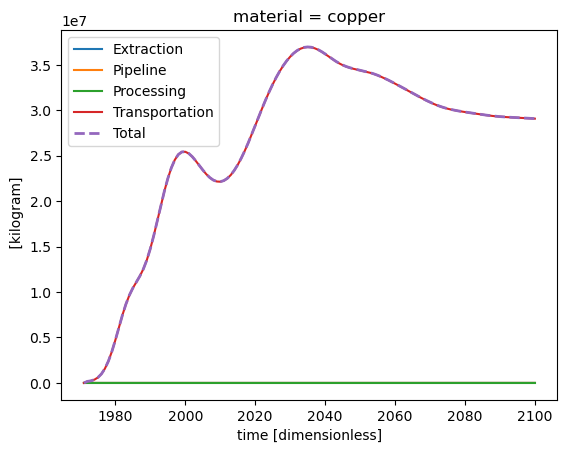

In [27]:
#plot for steel in all regions and types for each sector plotted on the same graph to compare the sectors.
extr = all_output["SSP2_baseline"].ff_extr["outflow_by_cohort_materials"].to_array().sel(material="copper").sum(dim="Type").sum(dim="Region")
extr.plot(label="Extraction")

pipe = all_output["SSP2_baseline"].ff_pipe["outflow_by_cohort_materials"].to_array().sel(material="copper").sum(dim="Type").sum(dim="Region")
pipe.plot(label="Pipeline")

proc = all_output["SSP2_baseline"].ff_proc["outflow_by_cohort_materials"].to_array().sel(material="copper").sum(dim="Type").sum(dim="Region")
proc.plot(label="Processing")

trp = all_output["SSP2_baseline"].ff_trp["outflow_by_cohort_materials"].to_array().sel(material="copper").sum(dim="Type").sum(dim="Region")
trp.plot(label="Transportation")

# Sum of all
total = extr + pipe + proc + trp
total.plot(label="Total", linewidth=2, linestyle="--")

print(total.sel(time=[2019, 2050]).to_series())

plt.legend()

time
2019    2.621517e+08
2050    3.432055e+08
dtype: float64


/Applications/anaconda3/envs/imagepy312_dev/lib/python3.12/site-packages/xarray/core/variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


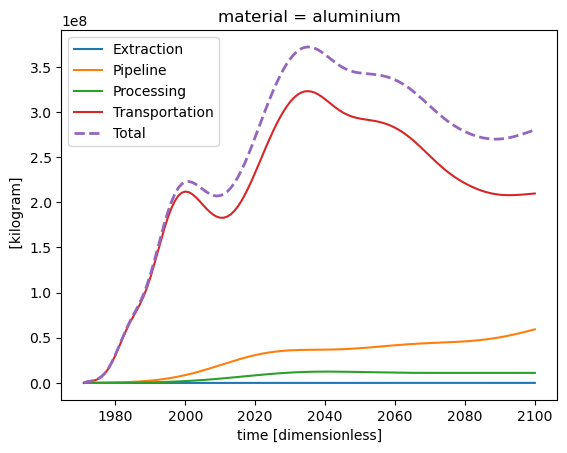

In [28]:
#plot for steel in all regions and types for each sector plotted on the same graph to compare the sectors.
extr = all_output["SSP2_baseline"].ff_extr["outflow_by_cohort_materials"].to_array().sel(material="aluminium").sum(dim="Type").sum(dim="Region")
extr.plot(label="Extraction")

pipe = all_output["SSP2_baseline"].ff_pipe["outflow_by_cohort_materials"].to_array().sel(material="aluminium").sum(dim="Type").sum(dim="Region")
pipe.plot(label="Pipeline")

proc = all_output["SSP2_baseline"].ff_proc["outflow_by_cohort_materials"].to_array().sel(material="aluminium").sum(dim="Type").sum(dim="Region")
proc.plot(label="Processing")

trp = all_output["SSP2_baseline"].ff_trp["outflow_by_cohort_materials"].to_array().sel(material="aluminium").sum(dim="Type").sum(dim="Region")
trp.plot(label="Transportation")

# Sum of all
total = extr + pipe + proc + trp
total.plot(label="Total", linewidth=2, linestyle="--")

print(total.sel(time=[2019, 2050]).to_series())

plt.legend()

time
2019    3.616549e+10
2050    3.254240e+10
dtype: float64


/Applications/anaconda3/envs/imagepy312_dev/lib/python3.12/site-packages/xarray/core/variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


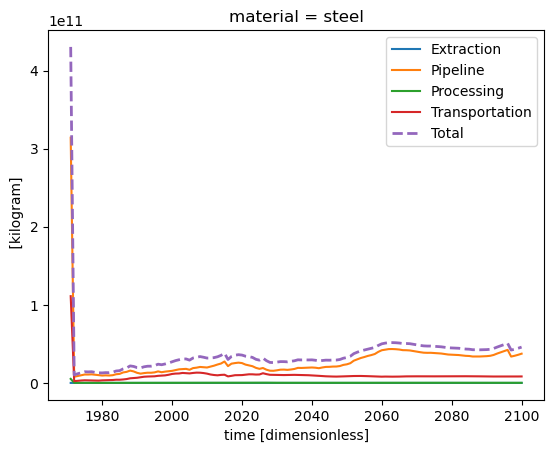

In [29]:
#plot for steel in all regions and types for each sector plotted on the same graph to compare the sectors.
extr = all_output["SSP2_baseline"].ff_extr["inflow_materials"].to_array().sel(material="steel").sum(dim="Type").sum(dim="Region")
extr.plot(label="Extraction")

pipe = all_output["SSP2_baseline"].ff_pipe["inflow_materials"].to_array().sel(material="steel").sum(dim="Type").sum(dim="Region")
pipe.plot(label="Pipeline")

proc = all_output["SSP2_baseline"].ff_proc["inflow_materials"].to_array().sel(material="steel").sum(dim="Type").sum(dim="Region")
proc.plot(label="Processing")

trp = all_output["SSP2_baseline"].ff_trp["inflow_materials"].to_array().sel(material="steel").sum(dim="Type").sum(dim="Region")
trp.plot(label="Transportation")

# Sum of all
total = extr + pipe + proc + trp
total.plot(label="Total", linewidth=2, linestyle="--")
print(total.sel(time=[2019, 2050]).to_series())
plt.legend()

time
2019    3.405244e+07
2050    2.966524e+07
dtype: float64


/Applications/anaconda3/envs/imagepy312_dev/lib/python3.12/site-packages/xarray/core/variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


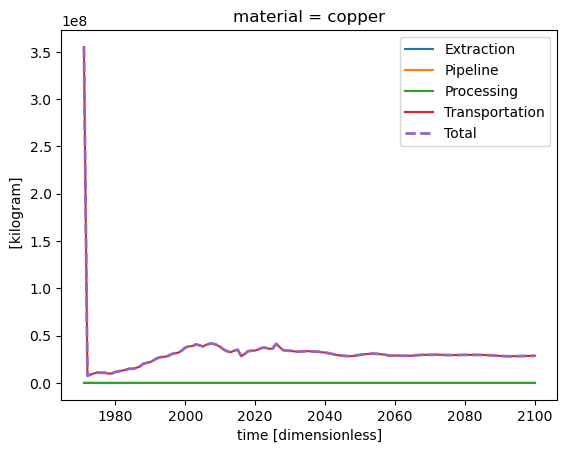

In [30]:
#plot for steel in all regions and types for each sector plotted on the same graph to compare the sectors.
extr = all_output["SSP2_baseline"].ff_extr["inflow_materials"].to_array().sel(material="copper").sum(dim="Type").sum(dim="Region")
extr.plot(label="Extraction")

pipe = all_output["SSP2_baseline"].ff_pipe["inflow_materials"].to_array().sel(material="copper").sum(dim="Type").sum(dim="Region")
pipe.plot(label="Pipeline")

proc = all_output["SSP2_baseline"].ff_proc["inflow_materials"].to_array().sel(material="copper").sum(dim="Type").sum(dim="Region")
proc.plot(label="Processing")

trp = all_output["SSP2_baseline"].ff_trp["inflow_materials"].to_array().sel(material="copper").sum(dim="Type").sum(dim="Region")
trp.plot(label="Transportation")

# Sum of all
total = extr + pipe + proc + trp
total.plot(label="Total", linewidth=2, linestyle="--")
print(total.sel(time=[2019, 2050]).to_series())
plt.legend()

/Applications/anaconda3/envs/imagepy312_dev/lib/python3.12/site-packages/xarray/core/variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


time
2019    3.425007e+08
2050    2.832664e+08
dtype: float64


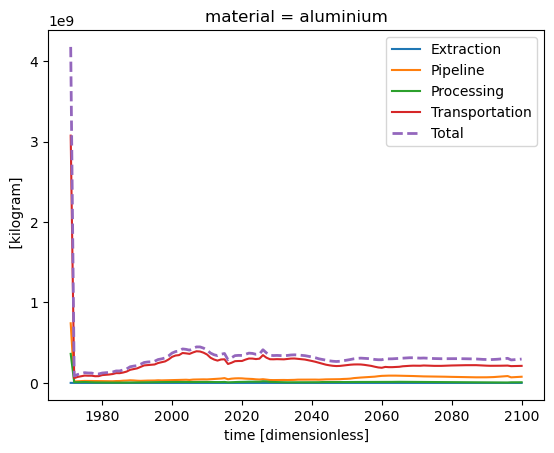

In [31]:
#plot for steel in all regions and types for each sector plotted on the same graph to compare the sectors.
extr = all_output["SSP2_baseline"].ff_extr["inflow_materials"].to_array().sel(material="aluminium").sum(dim="Type").sum(dim="Region")
extr.plot(label="Extraction")

pipe = all_output["SSP2_baseline"].ff_pipe["inflow_materials"].to_array().sel(material="aluminium").sum(dim="Type").sum(dim="Region")
pipe.plot(label="Pipeline")

proc = all_output["SSP2_baseline"].ff_proc["inflow_materials"].to_array().sel(material="aluminium").sum(dim="Type").sum(dim="Region")
proc.plot(label="Processing")

trp = all_output["SSP2_baseline"].ff_trp["inflow_materials"].to_array().sel(material="aluminium").sum(dim="Type").sum(dim="Region")
trp.plot(label="Transportation")

# Sum of all
total = extr + pipe + proc + trp
total.plot(label="Total", linewidth=2, linestyle="--")

plt.legend()
print(total.sel(time=[2019, 2050]).to_series())